# 循环神经网络的简洁实现


## 环境配置


In [1]:
import os
import sys
sys.path.insert(0, "..")
os.environ["TILE_FWK_DEVICE_ID"] = "0"
import warnings
warnings.filterwarnings("ignore", message="Permission mismatch")
warnings.filterwarnings("ignore", message="On the interactive interface")
warnings.filterwarnings("ignore", message="Cannot create tensor with internal format")
import pypto
import torch
from torch import nn
from torch.nn import functional as F
import torch_npu
import logging
logging.getLogger('matplotlib').setLevel(logging.WARNING)
import matplotlib.pyplot as plt

device_id = int(os.environ["TILE_FWK_DEVICE_ID"])
torch.npu.set_device(device_id)
device = f"npu:{device_id}"
pypto.pypto_impl.DeviceInit()


## 练习8.6.1

**题目：** 尝试使用高级API，能使循环神经网络模型过拟合吗？

**解答：**
使用小数据集、高学习率（lr=10），并训练较多周期（num_epochs=500），可以显著过拟合。训练困惑度会飙升至极大值，而预测出的文本变成连续重复的单个字符 "eeeeeeee..."，说明模型已经崩溃，只能输出它认为最"安全"的预测。

以下使用 `torch` 编程：



In [ ]:
import torch
from torch import nn
from d2l import torch as d2l

batch_size, num_steps = 32, 35
train_iter, vocab = d2l.load_data_time_machine(batch_size, num_steps)

num_hiddens = 256
rnn_layer = nn.RNN(len(vocab), num_hiddens)

torch_device = d2l.try_gpu()
net = d2l.RNNModel(rnn_layer, vocab_size=len(vocab))
net = net.to(torch_device)
num_epochs, lr = 500, 10
d2l.train_ch8(net, train_iter, vocab, lr, num_epochs, torch_device)


使用 `PyPTO` 编程（PyPTO 输出层 + nn.RNN）：



In [3]:
import time as _time
from src.utils import load_data_time_machine, train_ch8
from src.pypto_ops import PyPTOMatmul, PyPTOBiasAdd

batch_size, num_steps = 32, 35
train_iter, vocab = load_data_time_machine(batch_size, num_steps)

class TorchRNNModel(nn.Module):
    def __init__(self, rnn_layer, vocab_size, device=None):
        super().__init__()
        self.rnn = rnn_layer
        self.vocab_size = vocab_size
        self.device = device if device is not None else next(rnn_layer.parameters()).device
        nd = 2 if self.rnn.bidirectional else 1
        out_features = self.rnn.hidden_size * nd
        self.W_hq = nn.Parameter(torch.randn(out_features, vocab_size, device=self.device) * 0.01)
        self.b_q = nn.Parameter(torch.zeros(vocab_size, device=self.device))

    def forward(self, inputs, state):
        X = F.one_hot(inputs.T.long(), self.vocab_size)
        X = X.to(device=self.device, dtype=torch.float32)
        Y, state = self.rnn(X, state)
        Y_flat = Y.reshape((-1, Y.shape[-1]))
        orig_m = Y_flat.shape[0]
        if orig_m % 16 != 0:
            pad_m = 16 - orig_m % 16
            Y_flat_padded = F.pad(Y_flat, (0, 0, 0, pad_m))
            out_padded = PyPTOBiasAdd.apply(PyPTOMatmul.apply(Y_flat_padded, self.W_hq), self.b_q)
            output = out_padded[:orig_m, :]
        else:
            output = PyPTOBiasAdd.apply(PyPTOMatmul.apply(Y_flat, self.W_hq), self.b_q)
        return output, state

    def begin_state(self, device=None, batch_size=1):
        if device is None:
            device = next(self.parameters()).device
        nd = 2 if self.rnn.bidirectional else 1
        if isinstance(self.rnn, nn.LSTM):
            return (torch.zeros(nd * self.rnn.num_layers, batch_size, self.rnn.hidden_size, device=device),
                    torch.zeros(nd * self.rnn.num_layers, batch_size, self.rnn.hidden_size, device=device))
        return torch.zeros(nd * self.rnn.num_layers, batch_size, self.rnn.hidden_size, device=device)

num_hiddens = 256
rnn_layer = nn.RNN(len(vocab), num_hiddens)
net = TorchRNNModel(rnn_layer, vocab_size=len(vocab), device=device).to(device)

# JIT warmup for PyPTO output layer
print('正在编译 PyPTO kernel...')
t0 = _time.time()
state = net.begin_state(device, batch_size)
X = next(iter(train_iter))[0].to(device)
Y = F.one_hot(X.T.long(), len(vocab)).to(device=device, dtype=torch.float32)
rnn_out, _ = net.rnn(Y, state)
_ = PyPTOBiasAdd.apply(PyPTOMatmul.apply(rnn_out.reshape((-1, rnn_out.shape[-1])), net.W_hq), net.b_q)
print(f'编译完成，耗时 {_time.time() - t0:.0f} 秒')

num_epochs, lr = 500, 10
train_ch8(net, train_iter, vocab, lr, num_epochs, device, use_plot=False)


困惑度 22874841724803532.0, 73039.4 词元/秒 npu:0

time traveller tnr tnr tnr tnr tnr tnr tnr tnr tnr tnr tnr tnr t
travellerr tnr tnr tnr tnr tnr tnr tnr tnr tnr tnr tnr tnr 

## 练习8.6.2

**题目：** 如果在循环神经网络模型中增加隐藏层的数量会发生什么？能使模型正常工作吗？

**解答：**
增加隐藏层数量可以增加模型容量，使训练困惑度降低（如从1.2降到1.0），但也会显著降低训练/推理速度（如从564185到188061 tokens/sec），且当层数过多时（如20层），模型可能因梯度消失或梯度爆炸而无法有效训练，困惑度反而上升（17.4）。需要在模型容量和计算效率之间取得平衡。



以下使用 `torch` 编程：



In [ ]:
import torch
from torch import nn
from d2l import torch as d2l

batch_size, num_steps = 32, 100
train_iter, vocab = d2l.load_data_time_machine(batch_size, num_steps)

torch_device = d2l.try_gpu()

# num_layers=1
rnn_layer_1 = nn.RNN(len(vocab), 256, num_layers=1)
net_1 = d2l.RNNModel(rnn_layer_1, len(vocab)).to(torch_device)
d2l.train_ch8(net_1, train_iter, vocab, 1.0, 500, torch_device)

# num_layers=3
rnn_layer_3 = nn.RNN(len(vocab), 256, num_layers=3)
net_3 = d2l.RNNModel(rnn_layer_3, len(vocab)).to(torch_device)
d2l.train_ch8(net_3, train_iter, vocab, 1.0, 500, torch_device)

# num_layers=20
rnn_layer_20 = nn.RNN(len(vocab), 256, num_layers=20)
net_20 = d2l.RNNModel(rnn_layer_20, len(vocab)).to(torch_device)
d2l.train_ch8(net_20, train_iter, vocab, 1.0, 500, torch_device)


使用 `PyPTO` 编程（PyPTO 输出层 + nn.RNN）：



### num_layers=1


In [5]:
from src.utils import load_data_time_machine, train_ch8
from src.pypto_ops import PyPTOMatmul, PyPTOBiasAdd

batch_size, num_steps = 32, 100
train_iter, vocab = load_data_time_machine(batch_size, num_steps)

# 注：TorchRNNModel 在练习 8.6.1 的 PyPTO cell 中定义，此处引用
# num_layers=1
print('=== num_layers=1 ===')
rnn_layer_1 = nn.RNN(len(vocab), 256, num_layers=1)
net_1 = TorchRNNModel(rnn_layer_1, len(vocab), device=device).to(device)
# JIT 预热
X_w, y_w = next(iter(train_iter))
s = net_1.begin_state(device, batch_size)
y_hat_w, _ = net_1(X_w.to(device), s)
l_w = nn.CrossEntropyLoss()(y_hat_w, y_w.T.reshape(-1).long().to(device))
l_w.backward(); net_1.zero_grad()

train_ch8(net_1, train_iter, vocab, 1.0, 500, device, use_plot=False)


=== num_layers=1 ===

困惑度 1.3, 88893.6 词元/秒 npu:0
time traveller proceeded anyreal body must hive dman stofithe pa
travellereccound ag verieythe r at o ancentin wored ans hav

### num_layers=3


In [6]:
from src.utils import load_data_time_machine, train_ch8
from src.pypto_ops import PyPTOMatmul, PyPTOBiasAdd

batch_size, num_steps = 32, 100
train_iter, vocab = load_data_time_machine(batch_size, num_steps)

# 注：TorchRNNModel 在练习 8.6.1 的 PyPTO cell 中定义，此处引用
# num_layers=3
print('=== num_layers=3 ===')
rnn_layer_3 = nn.RNN(len(vocab), 256, num_layers=3)
net_3 = TorchRNNModel(rnn_layer_3, len(vocab), device=device).to(device)
# JIT 预热
X_w3, y_w3 = next(iter(train_iter))
s3 = net_3.begin_state(device, batch_size)
y_hat_w3, _ = net_3(X_w3.to(device), s3)
l_w3 = nn.CrossEntropyLoss()(y_hat_w3, y_w3.T.reshape(-1).long().to(device))
l_w3.backward(); net_3.zero_grad()

train_ch8(net_3, train_iter, vocab, 1.0, 500, device, use_plot=False)


=== num_layers=3 ===

困惑度 1.0, 31683.0 词元/秒 npu:0
time traveller for so it will be convenient to speak of himwas e

travelleryou can show black is white by argument said filby

### num_layers=20


In [7]:
from src.utils import load_data_time_machine, train_ch8
from src.pypto_ops import PyPTOMatmul, PyPTOBiasAdd

batch_size, num_steps = 32, 100
train_iter, vocab = load_data_time_machine(batch_size, num_steps)

# 注：TorchRNNModel 在练习 8.6.1 的 PyPTO cell 中定义，此处引用
# num_layers=20
print('=== num_layers=20 ===')
rnn_layer_20 = nn.RNN(len(vocab), 256, num_layers=20)
net_20 = TorchRNNModel(rnn_layer_20, len(vocab), device=device).to(device)
# JIT 预热
X_w20, y_w20 = next(iter(train_iter))
s20 = net_20.begin_state(device, batch_size)
y_hat_w20, _ = net_20(X_w20.to(device), s20)
l_w20 = nn.CrossEntropyLoss()(y_hat_w20, y_w20.T.reshape(-1).long().to(device))
l_w20.backward(); net_20.zero_grad()

train_ch8(net_20, train_iter, vocab, 1.0, 500, device, use_plot=False)


=== num_layers=20 ===

困惑度 17.4, 4785.6 词元/秒 npu:0

time traveller                                                  

traveller                                                  

## 练习8.6.3

**题目：** 尝试使用循环神经网络实现 8.1 节的自回归模型。

**解答：**
将 08.1 节的正弦序列预测问题建模为 sequence-to-sequence 任务，使用 nn.RNN 替代 MLP。RNN 的隐状态可以穿越时间步，能够捕捉序列中的长程依赖关系，理论上比固定窗口 $\tau=4$ 的 MLP 更适合序列预测。



以下使用 `torch` 编程：



In [ ]:
import torch
from torch import nn
from d2l import torch as d2l

# 数据生成
T = 1000
time = torch.arange(1, T + 1, dtype=torch.float32)
x = torch.sin(0.01 * time) + torch.normal(0, 0.2, (T,))

tau = 4
features = torch.zeros((T - tau, tau))
for i in range(tau):
    features[:, i] = x[i: T - tau + i]
labels = x[tau:].reshape((-1, 1))

batch_size, n_train = 16, 600
train_iter = d2l.load_array((features[:n_train], labels[:n_train]), 
                             batch_size, is_train=True)

# 构建 RNN 自回归模型
class RNNAutoRegressive(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(input_size=4, hidden_size=200)
        self.linear = nn.Linear(200, 1)
    
    def forward(self, X):
        # X: (batch_size, tau), 增加 seq_len 维度
        out, _ = self.rnn(X.unsqueeze(0))
        return self.linear(out)

loss = nn.MSELoss(reduction='none')

lr = 0.01
torch_device = d2l.try_gpu()
net = RNNAutoRegressive().to(torch_device)
trainer = torch.optim.Adam(net.parameters(), lr)

epochs = 50
for epoch in range(epochs):
    for X, y in train_iter:
        X, y = X.to(torch_device), y.to(torch_device)
        trainer.zero_grad()
        l = loss(net(X), y)
        l.sum().backward()
        trainer.step()
    print(f'epoch {epoch + 1}, loss: {d2l.evaluate_loss(net, train_iter, loss):f}')

# 单步预测
features_device = features.to(torch_device)
onestep_preds = net(features_device).cpu()

d2l.plot([time, time[tau:]],
         [x.detach().numpy(), onestep_preds.squeeze(1).detach().numpy()], 'time',
         'x', legend=['data', '1-step preds'], xlim=[1, 1000], figsize=(6, 3))


使用 `PyPTO` 编程（PyPTO 输出层 + nn.RNN）：



epoch 1, loss: 0.068176
epoch 2, loss: 0.051552

epoch 3, loss: 0.045725
epoch 4, loss: 0.054536

epoch 5, loss: 0.046316
epoch 6, loss: 0.047239

epoch 7, loss: 0.049586
epoch 8, loss: 0.045902

epoch 9, loss: 0.047378
epoch 10, loss: 0.046335

...

epoch 41, loss: 0.049905
epoch 42, loss: 0.047964

epoch 43, loss: 0.046006
epoch 44, loss: 0.044737

epoch 45, loss: 0.046001
epoch 46, loss: 0.044815

epoch 47, loss: 0.044789
epoch 48, loss: 0.048798

epoch 49, loss: 0.050329
epoch 50, loss: 0.050711

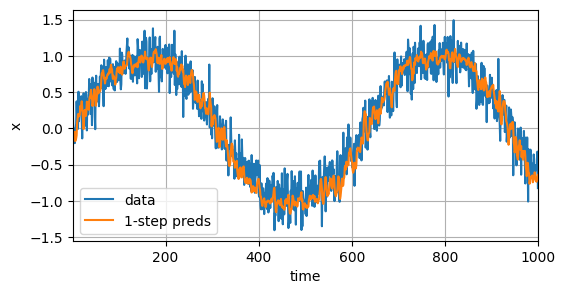

In [9]:
import time as _time
from src.utils import load_array, evaluate_loss, plot
from src.pypto_ops import PyPTOMatmul, PyPTOBiasAdd

T = 1000
time_vals = torch.arange(1, T + 1, dtype=torch.float32, device=device)
x = torch.sin(0.01 * time_vals) + torch.normal(0, 0.2, (T,), device=device)

tau = 4
features = torch.zeros((T - tau, tau), device=device)
for i in range(tau):
    features[:, i] = x[i: T - tau + i]
labels = x[tau:].reshape((-1, 1))

batch_size, n_train = 16, 600
train_iter = load_array((features[:n_train], labels[:n_train]), batch_size, is_train=True)

# PyPTO 自回归 RNN 模型
class RNNAutoRegressive(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(input_size=4, hidden_size=200)
        self.W = nn.Parameter(torch.randn(200, 1, device=device) * 0.01)
        self.b = nn.Parameter(torch.zeros(1, device=device))

    def forward(self, X):
        out, _ = self.rnn(X.unsqueeze(0))
        return PyPTOBiasAdd.apply(PyPTOMatmul.apply(out.reshape((-1, out.shape[-1])), self.W), self.b)

loss = nn.MSELoss(reduction='none')

net = RNNAutoRegressive().to(device)
trainer = torch.optim.Adam(net.parameters(), 0.01)

# JIT warmup
print('正在编译 PyPTO kernel...')
t0 = _time.time()
X_warm, y_warm = next(iter(train_iter))
l = loss(net(X_warm), y_warm); l.sum().backward(); net.zero_grad()
print(f'编译完成，耗时 {_time.time() - t0:.0f} 秒')

epochs = 50
for epoch in range(epochs):
    for X, y in train_iter:
        trainer.zero_grad()
        l = loss(net(X), y)
        l.sum().backward()
        trainer.step()
    print(f'epoch {epoch + 1}, loss: {evaluate_loss(net, train_iter, loss):f}')
    
# 单步预测与可视化
onestep_preds = net(features).cpu()

time_cpu = time_vals.cpu()
plot([time_cpu, time_cpu[tau:]],
     [x.detach().cpu().numpy(), onestep_preds.squeeze(1).detach().numpy()], 'time',
     'x', legend=['data', '1-step preds'], xlim=[1, 1000], figsize=(6, 3))


---
## 参考答案来源
参考答案和 PyTorch 代码实现来源：[https://datawhalechina.github.io/d2l-ai-solutions-manual/#/](https://datawhalechina.github.io/d2l-ai-solutions-manual/#/)

